<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>



# **Final Project: Boston Housing**


##### Estimated time needed: **60** minutes


#### Import the required libraries we need for the lab.


In [6]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [38]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats as levene
import statsmodels.api as sm
from statsmodels.formula.api import ols


#### Read the dataset in the csv file from the URL


In [8]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [9]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [12]:
# Task 1: Familiarize Yourself with the Dataset
# Display the first 5 rows of the dataset.

boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [17]:
#  Display the data types of each column.
boston_df.dtypes

Unnamed: 0      int64
CRIM          float64
ZN            float64
INDUS         float64
CHAS          float64
NOX           float64
RM            float64
AGE           float64
DIS           float64
RAD           float64
TAX           float64
PTRATIO       float64
LSTAT         float64
MEDV          float64
dtype: object

In [18]:
#  Check for missing values in each column.
boston_df.isnull().sum()

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64

In [19]:
# Check for duplicate rows.
boston_df.duplicated().sum()

0

In [20]:
# Display the correlation matrix of the dataset.
boston_df.corr()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
Unnamed: 0,1.000000,0.407407,-0.103393,0.399439,-0.003759,0.398736,-0.079971,0.203784,-0.302211,0.686002,0.666626,0.291074,0.258465,-0.226604
CRIM,0.407407,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
ZN,-0.103393,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
INDUS,0.399439,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
CHAS,-0.003759,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
NOX,0.398736,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
RM,-0.079971,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
AGE,0.203784,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
DIS,-0.302211,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
RAD,0.686002,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626


In [26]:
# Task 2: Generate Descriptive Statistics and Visualizations
# Display descriptive statistics of the dataset.
boston_df.describe()


,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


Text(0.5, 1.0, 'Boxplot Median value of owner-occupied homes')

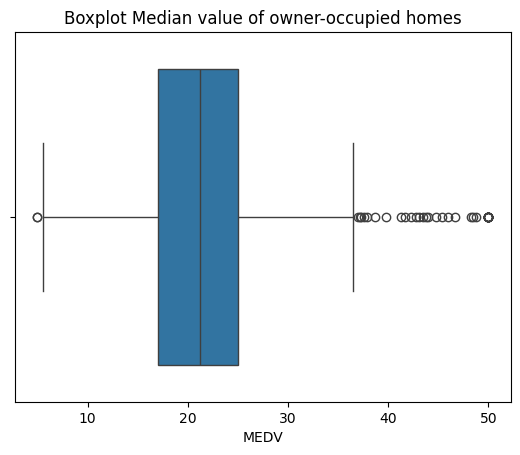

In [27]:
# Create a boxplot for MEDV (Median value of owner-occupied homes).
import seaborn as sns
sns.boxplot(x=boston_df['MEDV']).set_title('Boxplot Median value of owner-occupied homes')

<AxesSubplot:title={'center':'Charles River dummy variable'}, xlabel='CHAS'>

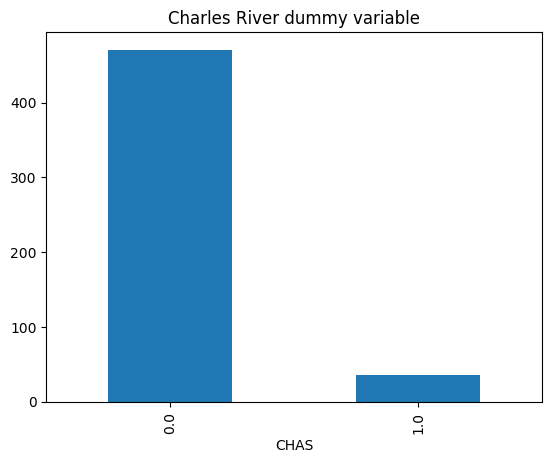

In [29]:
# Create a bar plot for CHAS (Charles River dummy variable).
boston_df['CHAS'].value_counts().plot(kind='bar',title='Charles River dummy variable')

<AxesSubplot:xlabel='age_group', ylabel='MEDV'>

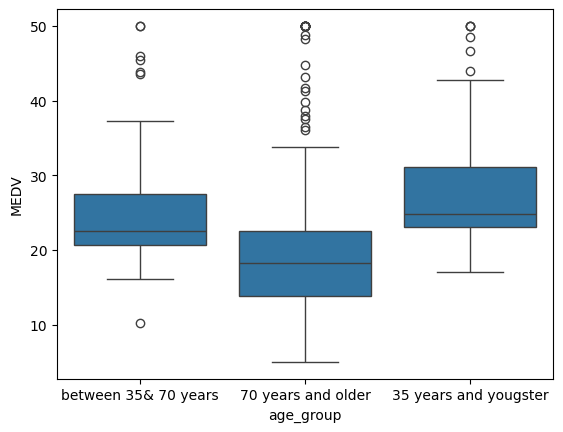

In [31]:
# Discretize AGE into three groups and create a boxplot of MEDV versus these groups:
boston_df.loc[(boston_df['AGE']<=35),'age_group']='35 years and yougster'
boston_df.loc[(boston_df['AGE']>35)&(boston_df['AGE']<70),'age_group']='between 35& 70 years'
boston_df.loc[(boston_df['AGE']>=70),'age_group']='70 years and older'
sns.boxplot(x='age_group',y='MEDV',data=boston_df)

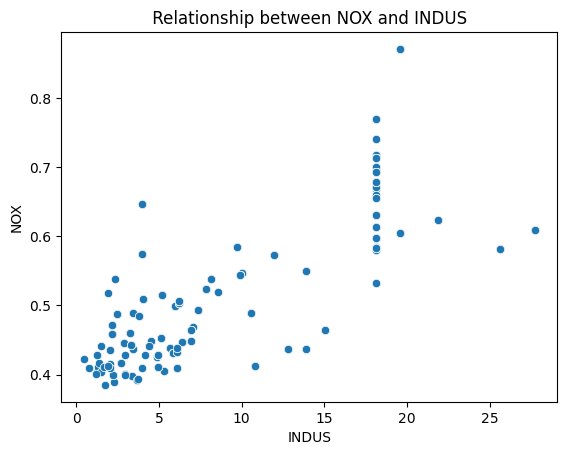

In [33]:
# Create a scatter plot showing the relationship between NOX (nitric oxide concentrations) and INDUS (non-retail business acres).
sns.scatterplot(x='INDUS',y='NOX',data=boston_df)
pyplot.title(' Relationship between NOX and INDUS ')
pyplot.show()

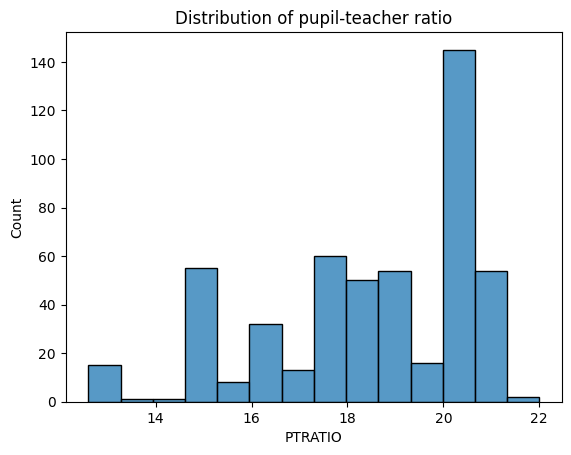

In [34]:
# Create a histogram for PTRATIO (pupil-teacher ratio).
sns.histplot(boston_df['PTRATIO'],kde=False)
pyplot.title('Distribution of pupil-teacher ratio')
pyplot.show()

In [47]:
#Task 3: Apply Statistical Tests
# Use Levene’s test to check if the variances of MEDV for homes bounded by the Charles River (CHAS = 1) and those not bounded (CHAS = 0) are equal.
from scipy.stats import levene
grp1=boston_df[boston_df['CHAS']==1]['MEDV']
grp0=boston_df[boston_df['CHAS']==0]['MEDV']
stats,p_val=levene(grp1,grp0)
print(f"Levene's test - Statastics: {stats:.4f}, p_val={p_val:.4f}")

Levene's test - Statastics: 4.5903, p_val=0.0326


In [52]:
# Perform a T-test to determine if there is a significant difference in MEDV between homes bounded and not bounded by the Charles River.
from scipy.stats import levene
grp1=boston_df[boston_df['CHAS']==1]['MEDV']
grp0=boston_df[boston_df['CHAS']==0]['MEDV']
stats,p_val=levene(grp1,grp0)
equal_var=(p_val > 0.05)
t_stats,t_p_val=levene(grp1, grp0, equal_var)
print(f"T test - Statastics: {t_stats:.4f}, p_val={t_p_val:.4f}")

T test - Statastics: 2.7893, p_val=0.0624


In [56]:
# Conduct an ANOVA test to compare MEDV among the three AGE groups created earlier.
from scipy.stats import f_oneway
anv_stat,anv_p_val=f_oneway(boston_df[boston_df['age_group']=='grp_a']['MEDV'],
                            boston_df[boston_df['age_group']=='grp_b']['MEDV'],
                            boston_df[boston_df['age_group']=='grp_c']['MEDV'])
print(f"ANOVA Test : Statistics={anv_stat:.4f},p value={anv_p_val:.4f} ")


<ipython-input-56-df3b84317262>:3: DegenerateDataWarning: at least one input has length 0
  anv_stat,anv_p_val=f_oneway(boston_df[boston_df['age_group']=='grp_a']['MEDV'],


ANOVA Test : Statistics=nan,p value=nan 


In [61]:
# Perform a Pearson correlation test to assess the relationship between NOX and INDUS.
from scipy.stats import pearsonr
corr,corr_p_val=pearsonr(boston_df['NOX'],boston_df['INDUS'])
print(f"Pearson correlation test oc Coefficient {corr:.4f} ")

Pearson correlation test oc Coefficient 0.7637 


In [63]:
# Fit a simple linear regression model to evaluate the impact of DIS (distance to employment centres) on MEDV. Report and interpret the regression results.
import statsmodels.api as sm

X=boston_df['DIS']
y=boston_df['MEDV']
X=sm.add_constant(X)
model=sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           1.21e-08
Time:                        20:26:13   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0